# Fake News detections.

In [36]:
# import
import os
import re
import csv
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from io import StringIO
from urllib.request import urlopen

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

In [37]:
# Data path
true_path = "../Data/True.csv"
fake_path = "../Data/Fake.csv"

In [38]:
# Read csv
data_true = pd.read_csv(true_path)
data_fake = pd.read_csv(fake_path)

In [39]:
data_true['class'] = 1
data_fake['class'] = 0

In [40]:
data = pd.concat([data_true, data_fake], axis= 0)
data.sample(5)

,title,text,subject,date,class
7846,Mark Zuckerberg Stands Strong With Black Live...,Facebook CEO Mark Zuckerberg has had about eno...,News,"February 26, 2016",0
13138,HERE’S HOW CROOKED HILLARY Deleted The “Money ...,Here s just one more piece to the puzzle Hilla...,politics,"Aug 29, 2016",0
11531,WOW! 83-YEAR OLD SENATOR Challenged By Teen To...,,politics,"Mar 1, 2017",0
3405,Trump not planning to invoke executive privile...,(Reuters) - U.S. President Donald Trump does n...,politicsNews,"June 3, 2017",1
8187,Trump says Fed keeping rates low because of pr...,WASHINGTON (Reuters) - Republican presidential...,politicsNews,"September 12, 2016",1


In [41]:
# Information about data
print("Thông tin dữ liệu:")
display(data.info())

print("\n5 dòng đầu:")
display(data.head())

print("\nTên cột:")
print(data.columns.tolist())

print("\nSố lượng giá trị thiếu:")
print(data.isna().sum())


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   class    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


None


5 dòng đầu:


,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1



Tên cột:
['title', 'text', 'subject', 'date', 'class']

Số lượng giá trị thiếu:
title      0
text       0
subject    0
date       0
class      0
dtype: int64


In [42]:
# pre clean data
data['content'] = data['title'] + ' ' +data['text']
data.drop(['title', 'subject', 'date', 'text'], axis=1, inplace=True)
data.sample(5)

,class,content
16523,0,MUST WATCH VIDEO! HERE’S THE MOST IMPORTANT AN...
3050,1,"As debt limit looms, House leaders eye biparti..."
21593,0,MOTHER OF 7 YR OLD CHARGED WITH “Endangerment”...
18715,0,SPINELESS GOP PROVES MAJORITY Means Nothing …S...
2064,1,"As tax debate heats up, Republicans tweak busi..."


In [43]:

data = data.drop_duplicates(subset=['content']).reset_index(drop=True)

print("Số dòng sau khi xóa trùng:", len(data))

Số dòng sau khi xóa trùng: 39105


In [44]:
data.reset_index(inplace= True)
data.sample(5)

,index,class,content
26696,26696,0,Trump Just Lost His Damn Mind On Twitter Afte...
6271,6271,1,Russian lawmakers give mixed reaction to Trump...
7308,7308,1,"Trump says discussed immigration, healthcare a..."
10176,10176,1,New York lawmakers expected to clear way for m...
24811,24811,0,Trump Supporter Says Facts Don’t Exist And Ge...


In [45]:
data.drop(['index'], axis=1, inplace= True)
data.sample(5)

,class,content
32102,0,WOW! MALE College Professor Caught On Camera B...
6444,1,Trump to order anti-hacking plan within 90 day...
28934,0,This Ted Cruz ‘Bad Lip Reading’ Is Everything...
12228,1,Russia and China discuss coordination on North...
23858,0,Sean Spicer Whines That SNL Was ‘Mean’ To Him...


In [46]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)
    
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+', '', text)
    
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return ' '.join(tokens)



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [47]:
data["content"] = data["content"].apply(preprocess_text)

In [48]:
data.sample(5)

,class,content
16821,1,fragment florence basilica fall kill tourist o...
36842,0,breaking clinton foundation find million previ...
37047,0,news graphic video michigan woman run rival ca...
7041,1,contender pick key job trump administration re...
22287,0,van struck muslim london horrifying incident t...


In [49]:
# slplit train and test.
x = data['content']
y = data['class']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size= 0.25,
    random_state= 42, stratify=y
)

In [50]:
label_names = {
    1 : 'True New',
    0 : 'Fake New'
}
print("Số mẫu train:", len(x_train))
print("Số mẫu test:", len(x_test))

print("\nPhân bố nhãn train:")
print(y_train.value_counts().sort_index().rename(index=label_names))
 
print("\nPhân bố nhãn test:")
print(y_test.value_counts().sort_index().rename(index=label_names))

Số mẫu train: 29328
Số mẫu test: 9777

Phân bố nhãn train:
class
Fake New    13431
True New    15897
Name: count, dtype: int64

Phân bố nhãn test:
class
Fake New    4477
True New    5300
Name: count, dtype: int64


In [51]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features= 20000,
        ngram_range= (1, 2),
        min_df=2, 
        max_df=0.95,
        sublinear_tf= True
    )),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
svm_pipeline.fit(x_train, y_train)

y_pred_svm = svm_pipeline.predict(x_test)

print("Result of SVM Linear:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['Fake', 'Real'],
    zero_division= 0,
    digits= 6
))

Result of SVM Linear:
              precision    recall  f1-score   support

        Fake   0.997985  0.995533  0.996757      4477
        Real   0.996234  0.998302  0.997267      5300

    accuracy                       0.997034      9777
   macro avg   0.997110  0.996917  0.997012      9777
weighted avg   0.997036  0.997034  0.997034      9777



# Otimazing Model SVM with GridSearchCV

In [52]:
param_grid = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "svm__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Tham số tốt nhất:")
print(grid_search.best_params_)

print("\nF1-score trung bình tốt nhất trên cross-validation:")
print(grid_search.best_score_)

best_svm_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tham số tốt nhất:
{'svm__C': 1, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

F1-score trung bình tốt nhất trên cross-validation:
0.9968583940757156


# Evaluate model after otimazing

In [53]:
y_pred_best_svm = best_svm_model.predict(x_test)

svm_accuracy = accuracy_score(y_test, y_pred_best_svm)
svm_precision = precision_score(y_test, y_pred_best_svm, zero_division=0)
svm_recall = recall_score(y_test, y_pred_best_svm, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_best_svm, zero_division=0)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)

print("\nResult:")
print(classification_report(
    y_test,
    y_pred_best_svm,
    target_names=["Fake", "Real"],
    zero_division=0,
    digits=6
))

Accuracy: 0.9970338549657359
Precision: 0.9960474308300395
Recall: 0.9984905660377359
F1-score: 0.9972675021200414

Result:
              precision    recall  f1-score   support

        Fake   0.998208  0.995309  0.996757      4477
        Real   0.996047  0.998491  0.997268      5300

    accuracy                       0.997034      9777
   macro avg   0.997128  0.996900  0.997012      9777
weighted avg   0.997037  0.997034  0.997034      9777



# Confusion matrix

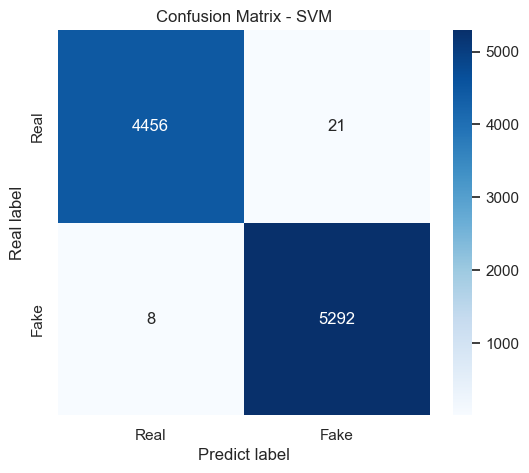

In [54]:
cm = confusion_matrix(y_test, y_pred_best_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

In [55]:
import joblib
joblib.dump(svm_pipeline, 'svm_pineline_model.jb')
print('Pineline is saved success')

Pineline is saved success
